# High-Resolution Subsurface Redox Interface Detection Algorithm (2026 Version)

## Methodology

This section details the algorithmic approach developed to automatically detect primary and secondary redox interfaces from high-frequency, in-situ subsurface redox potential ($E_H$) logs. The algorithm is designed to mimic the analytical judgment of a human geochemist—identifying the most significant, stable transition from oxidized to reduced conditions—while standardizing the process to eliminate subjective bias and handle high-resolution noise.

### 1. Pre-processing and Calibration
The raw redox measurements ($E_{raw}$) are recorded against an Ag/AgCl reference electrode. To convert these to the standard hydrogen electrode (SHE) scale ($E_H$), a temperature-compensated calibration shift is applied. For this study, a uniform calibration constant of $+225\text{ mV}$ is added to all raw measurements:
$$E_H = E_{raw} + 225$$

### 2. Resolution-Adaptive Smoothing
Subsurface probe insertion often generates high-frequency mechanical noise. To isolate the true geochemical gradient, the data is smoothed using a centered moving average. Because insertion speeds vary, the algorithm dynamically calculates the average depth step ($\Delta z_{avg}$) and sets a smoothing window ($W_s$) equivalent to approximately $0.5\text{ m}$ of travel:
$$W_s = \max\left(3, \left\lfloor\frac{0.5}{\Delta z_{avg}}\right\rfloor\right)$$
$$E_{smooth}(z) = \frac{1}{W_s} \sum_{i = -\lfloor W_s/2 \rfloor}^{\lfloor W_s/2 \rfloor} E_H(z_i)$$

### 3. Gradient Calculation (The "Drop")
To identify sharp transitions, we calculate the discrete spatial derivative over a larger window ($W_d$), representing approximately $1.5\text{ m}$. This defines the "Drop" magnitude at any given depth $z_i$ as the difference between the smoothed potential prior to the drop and the current smoothed potential:
$$W_d = \max\left(3, \left\lfloor\frac{1.5}{\Delta z_{avg}}\right\rfloor\right)$$
$$\Delta E(z_i) = E_{smooth}(z_{i - W_d}) - E_{smooth}(z_i)$$

### 4. Event Clustering and Peak Selection
Potential interface candidates are initially flagged where the drop magnitude exceeds a minimum threshold ($T_{drop} = 150\text{ mV}$). Because a single geochemical transition spans multiple continuous measurement points, these contiguous points are clustered into distinct "Drop Events". Within each cluster $C_k$, the singular depth representing the maximum gradient is selected as the preliminary interface peak ($z_{peak, k}$):
$$z_{peak, k} = \underset{z \in C_k}{\mathrm{argmax}} [\Delta E(z)]$$

### 5. Proximity Filtering
If multiple drop peaks occur within close spatial proximity ($\le 1.4\text{ m}$), they likely represent a single, complex transition zone rather than distinct geochemical horizons. In such cases, the algorithm retains only the peak with the largest magnitude, filtering out the lesser localized fluctuations.

### 6. Stable Reduced Stretch Identification
The core objective is to find the transition that leads into the primary, stable reduced aquifer zone, ignoring superficial "false drops" in the upper unsaturated zone. The algorithm identifies the largest contiguous block of data satisfying two conditions of stability and reduction:
1. **Reduced State:** $E_{smooth} < 100\text{ mV}$
2. **Stability:** $|\Delta E| < 75\text{ mV}$

### 7. Primary Interface Declaration ($Auto_1$)
The primary drop peak ($z_{main}$) is selected by finding the valid drop peak that immediately precedes or aligns with the start of the largest stable reduced stretch ($z_{stable, start}$). 

To ensure the final declared interface reflects a definitively reduced state, the algorithm descends from the peak depth $z_{main}$ until the raw redox potential drops below a conservative threshold ($T_{final} = 50\text{ mV}$). This adjusted depth is declared as the final primary interface:
$$Auto_1 = \min \{ z \ge z_{main} \mid E_H(z) < 50\text{ mV} \}$$

### 8. Secondary Interface Declaration ($Auto_2$)
In some complex geological settings, secondary redox boundaries exist. From the remaining valid drop peaks (excluding $Auto_1$), the algorithm evaluates them in order of magnitude. A secondary interface is declared at the depth of the largest remaining drop, provided that the raw redox potential at that specific depth indicates a sufficiently reduced state ($E_H(z) \le 100\text{ mV}$):
$$Auto_2 = z_{sec} \text{ where } E_H(z_{sec}) \le 100\text{ mV}$$
If no remaining peaks satisfy this condition, no secondary interface is reported.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import os

# Ensure the plots look nice
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)

### Python Implementation
The exact implementation of the algorithm described above.

In [2]:
def detect_interfaces(df_subset):
    """
    Applies the 2026 Interface Detection Algorithm to a single borehole log.
    Returns: m_z (Auto_1 depth), m_d (Auto_1 drop), s_z (Auto_2 depth), s_d (Auto_2 drop), df_debug
    """
    # 1. Pre-processing
    df_clean = df_subset.dropna(subset=["Redox_mV"]).copy()
    df_grouped = df_clean.groupby("Depth")["Redox_mV"].mean().reset_index().sort_values("Depth")
    
    depth = df_grouped["Depth"].values
    redox = df_grouped["Redox_mV"].values
    
    if len(depth) < 10:
        return np.nan, np.nan, np.nan, np.nan, df_clean
    
    # Calculate average depth step
    dz_avg = np.mean(np.diff(depth))
    if dz_avg <= 0: return np.nan, np.nan, np.nan, np.nan, df_clean
        
    df = pd.DataFrame({'Depth': depth, 'Redox': redox})
    
    # 2. Resolution-Adaptive Smoothing (approx 0.5m)
    win_smooth = max(3, int(0.5 / dz_avg))
    df['Smooth'] = df['Redox'].rolling(window=win_smooth, center=True, min_periods=1).mean()
    
    # 3. Gradient Calculation (approx 1.5m drop)
    win_drop = max(3, int(1.5 / dz_avg))
    df['Drop'] = df['Smooth'].shift(win_drop) - df['Smooth']
    
    min_drop = 150.0  
    
    # Collect candidates
    valid_candidates = []
    for i in range(win_drop, len(df)):
        if df['Drop'].iloc[i] > min_drop:
            valid_candidates.append({'z': df['Depth'].iloc[i], 'drop': df['Drop'].iloc[i], 'idx': i})
                
    if not valid_candidates:
        return np.nan, np.nan, np.nan, np.nan, df
        
    df_cand = pd.DataFrame(valid_candidates).sort_values('z')
    
    # 4. Event Clustering
    clusters = []
    current_cluster = [df_cand.iloc[0]]
    for j in range(1, len(df_cand)):
        row = df_cand.iloc[j]
        if row['idx'] - current_cluster[-1]['idx'] <= 3:
            current_cluster.append(row)
        else:
            clusters.append(current_cluster)
            current_cluster = [row]
    clusters.append(current_cluster)
    
    # Peak Selection
    interfaces_pre = []
    for cluster in clusters:
        cdf = pd.DataFrame(cluster)
        best_idx = cdf['drop'].idxmax()
        interfaces_pre.append({'z': cdf.loc[best_idx, 'z'], 'drop': cdf.loc[best_idx, 'drop']})
        
    # 5. Proximity Filtering (1.4m rule)
    final_interfaces = []
    interfaces_pre = sorted(interfaces_pre, key=lambda x: x['z'])
    
    if interfaces_pre:
        current_inf = interfaces_pre[0]
        for inf in interfaces_pre[1:]:
            if inf['z'] - current_inf['z'] <= 1.4:
                if inf['drop'] > current_inf['drop']:
                    current_inf = inf
            else:
                final_interfaces.append(current_inf)
                current_inf = inf
        final_interfaces.append(current_inf)
        
    # 6. Stable Reduced Stretch Identification
    df['is_stable'] = (df['Smooth'] < 100) & (df['Drop'].abs() < 75)
    
    df['block_id'] = (~df['is_stable']).cumsum()
    stable_blocks = df[df['is_stable']].groupby('block_id')
    
    best_block = None
    max_len = 0
    for block_id, block in stable_blocks:
        length = block['Depth'].max() - block['Depth'].min()
        if length > max_len:
            max_len = length
            best_block = block
            
    main_drop_inf = None
    if best_block is not None and not best_block.empty:
        z_stable_start = best_block['Depth'].min()
        # Minimize distance to the start of the block
        valid_main = [inf for inf in final_interfaces if inf['z'] <= z_stable_start + 1.0]
        if valid_main:
            main_drop_inf = min(valid_main, key=lambda x: abs(x['z'] - z_stable_start))
        else:
            main_drop_inf = min(final_interfaces, key=lambda x: abs(x['z'] - z_stable_start))
    else:
        main_drop_inf = sorted(final_interfaces, key=lambda x: x['drop'], reverse=True)[0]

    # 7. Primary Interface Declaration (50mV threshold adjustment)
    df_below = df[df['Depth'] >= main_drop_inf['z']]
    df_below_50 = df_below[df_below['Redox'] < 50.0]
    
    if not df_below_50.empty:
        adjusted_main_z = df_below_50.iloc[0]['Depth']
    else:
        adjusted_main_z = main_drop_inf['z']
        
    m_z = adjusted_main_z
    m_d = main_drop_inf['drop']
    
    # 8. Secondary Interface Declaration (100mV Threshold)
    s_z = np.nan
    s_d = np.nan
    secondary_threshold_mv = 100.0
    if len(final_interfaces) > 1:
        remaining = [inf for inf in final_interfaces if inf['z'] != main_drop_inf['z']]
        remaining = sorted(remaining, key=lambda x: x['drop'], reverse=True)
        for inf in remaining:
            inf_z = inf['z']
            redox_at_z = df.loc[df['Depth'] == inf_z, 'Redox'].values
            if len(redox_at_z) > 0 and redox_at_z[0] <= secondary_threshold_mv:
                s_z = inf_z
                s_d = inf['drop']
                break
        
    return m_z, m_d, s_z, s_d, df

### Example Visualization
We load a subset of the calibrated Master Redox dataset to demonstrate the algorithm visually.

In [3]:
# Load Master Redox and apply +225mV calibration
df_redox = pd.read_csv('../Python_Redox_Geochemistry/Redox/Master_Redox.csv')
df_redox['Redox_mV'] = df_redox['Redox_mV'] + 225.0
if 'DateTime' in df_redox.columns:
    df_redox['Date'] = pd.to_datetime(df_redox['DateTime']).dt.date

print(f"Loaded {len(df_redox)} data points.")

Loaded 31309 data points.


--- LOGS WITH SINGLE INTERFACE (Primary Only) ---


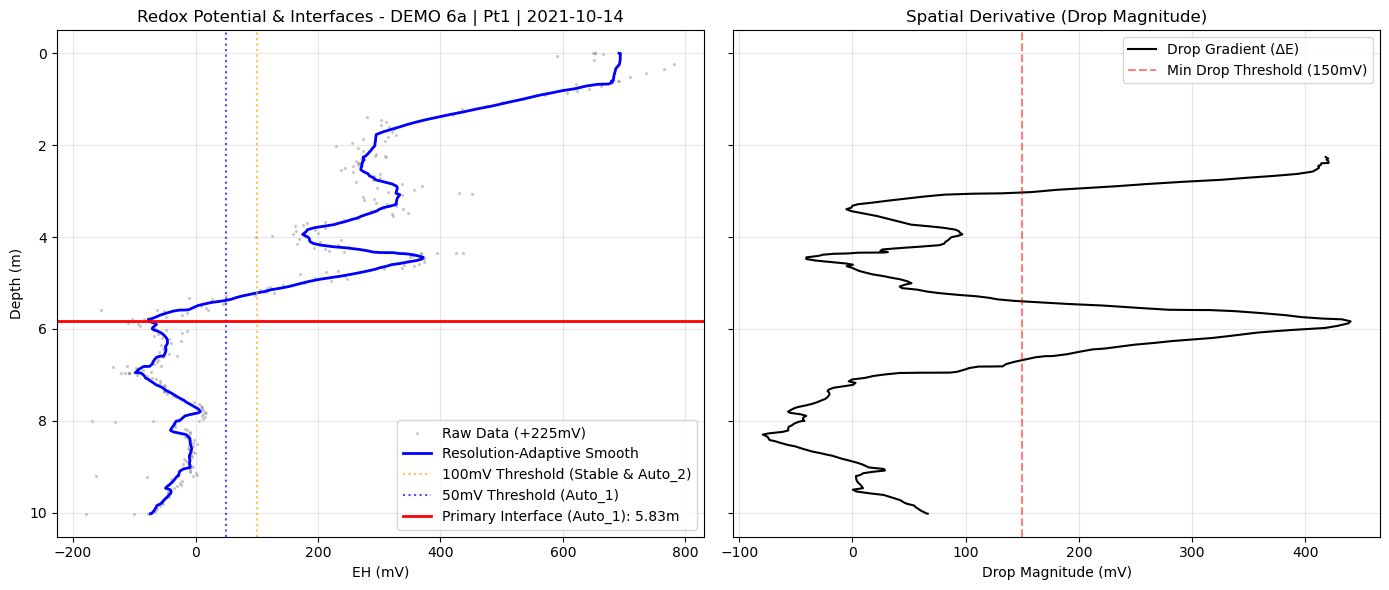

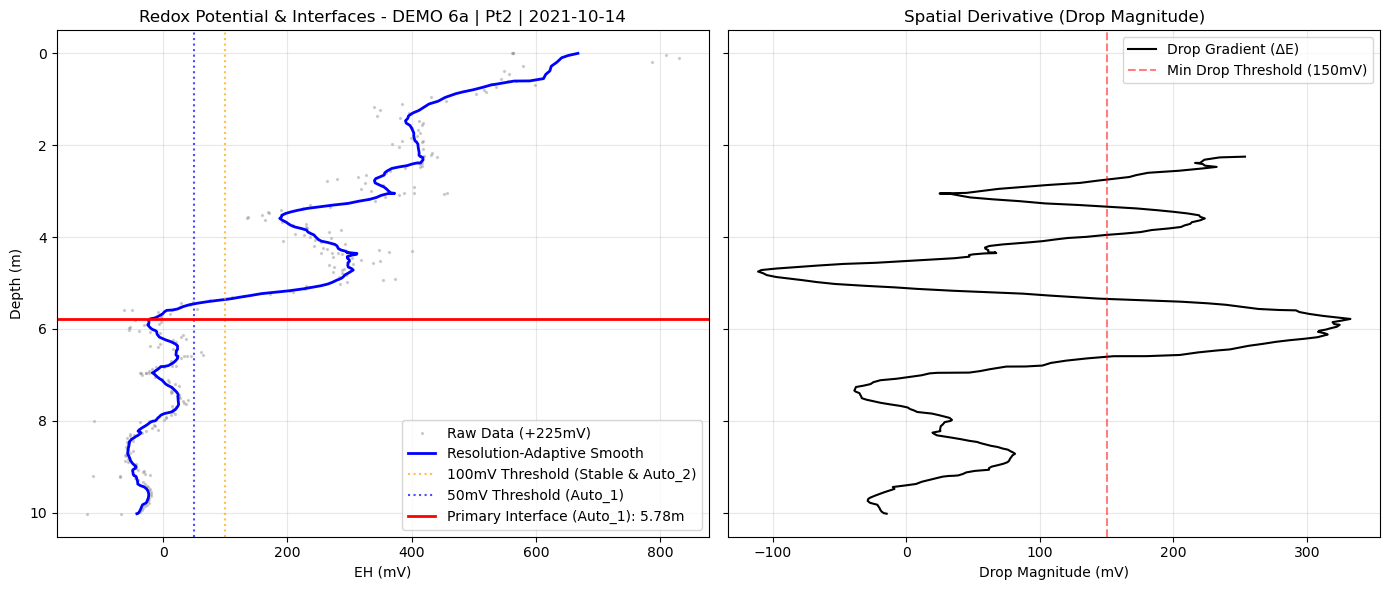

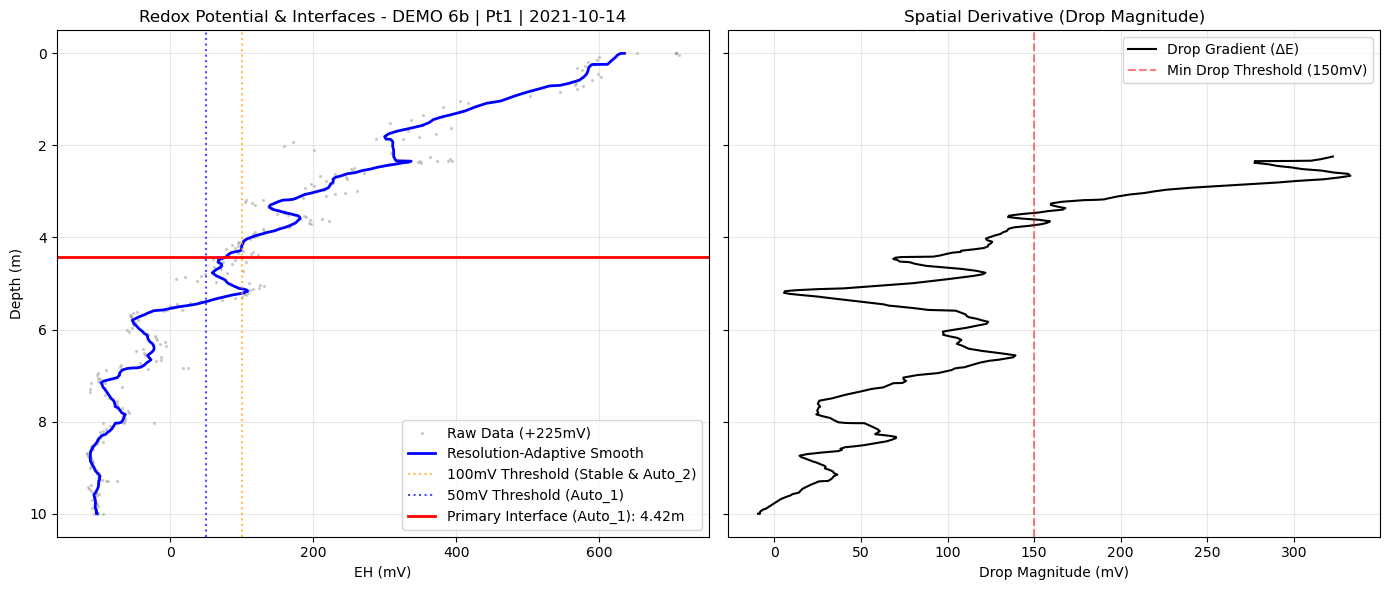


--- LOGS WITH DUAL INTERFACES (Primary and Secondary) ---


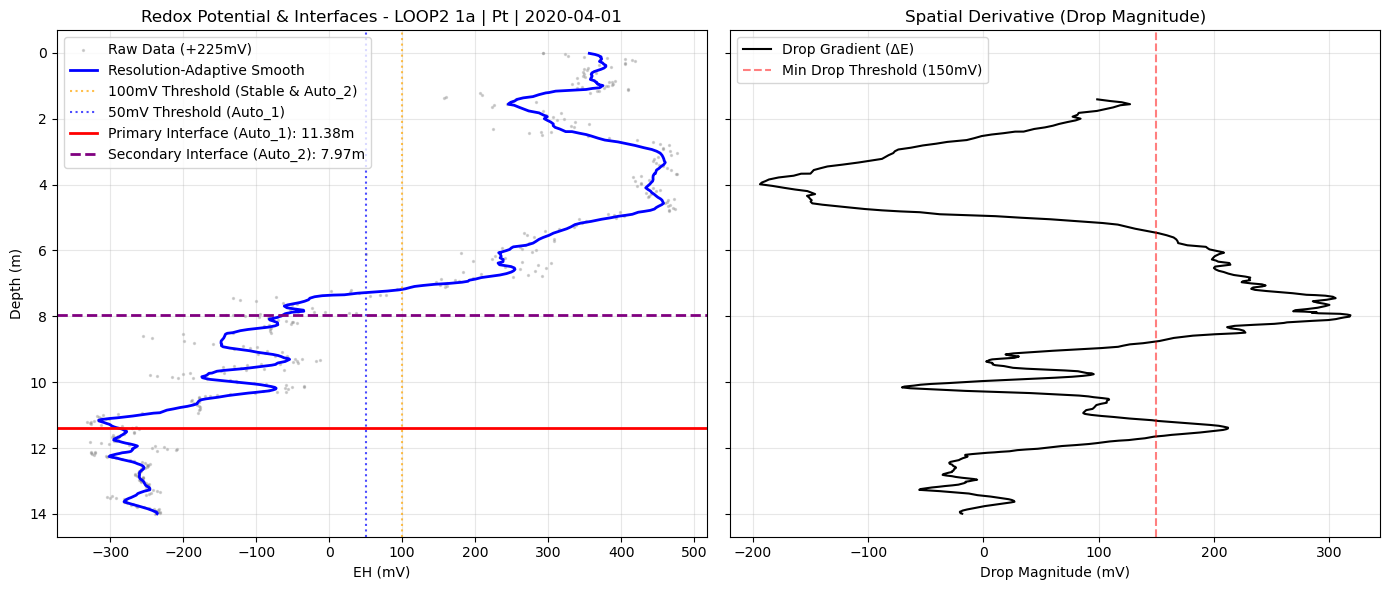

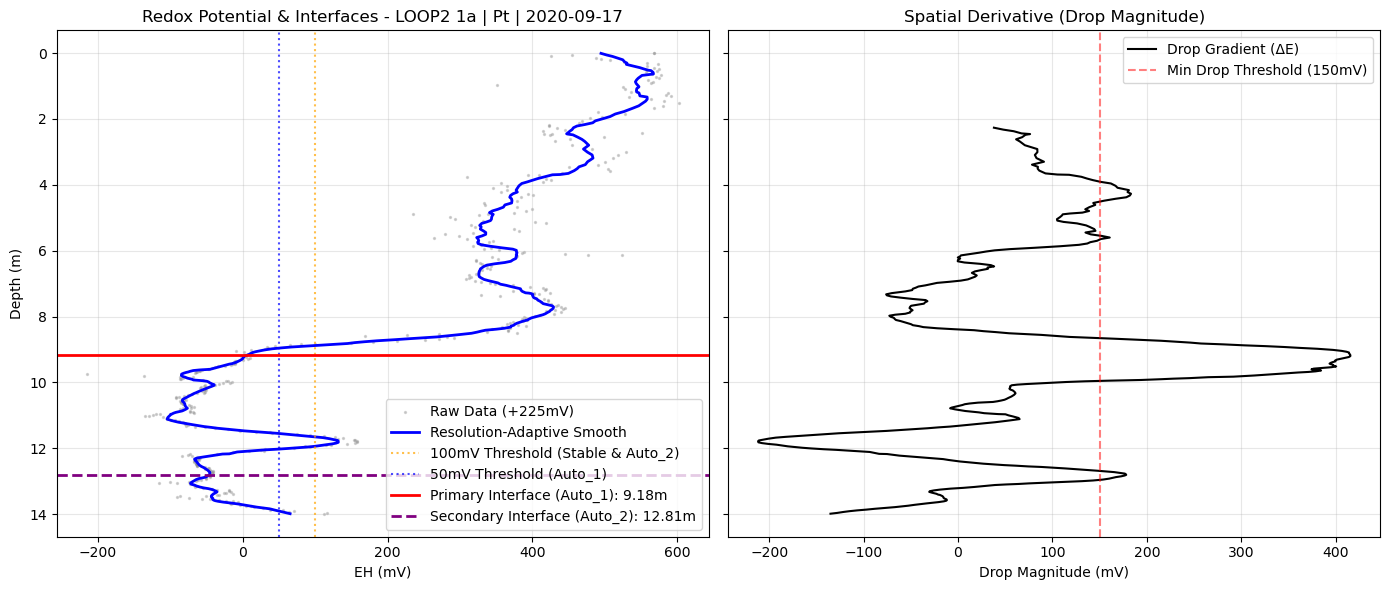

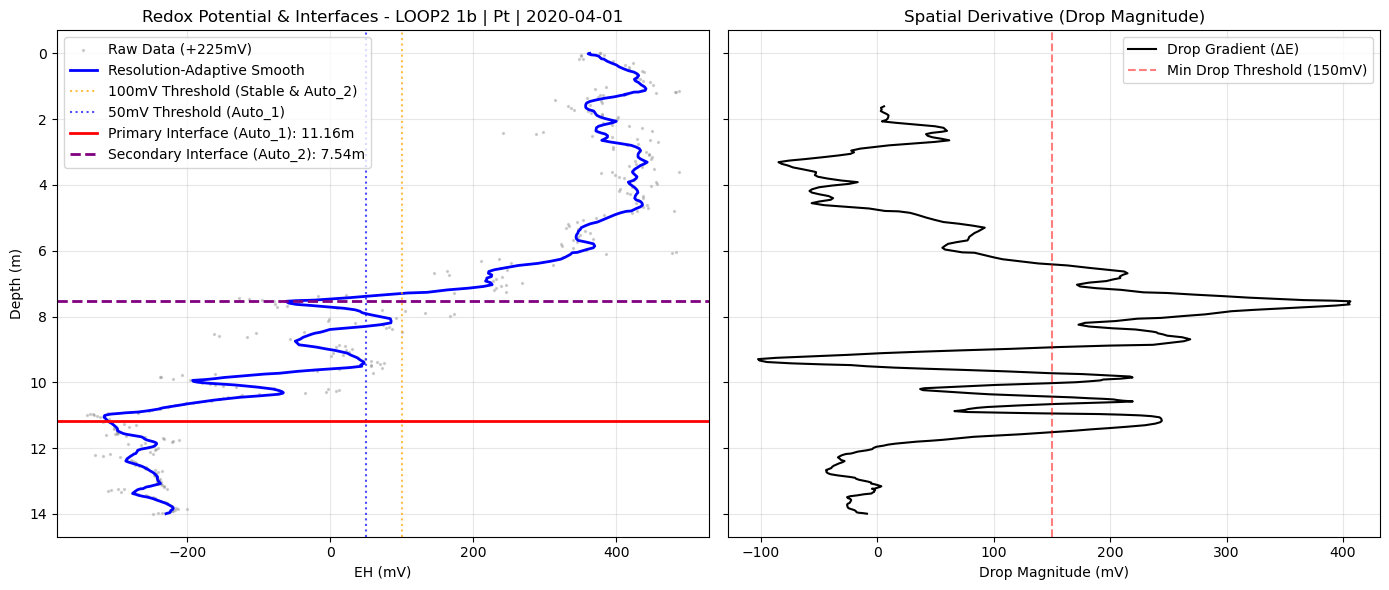

In [4]:
def plot_algorithm_demo(loop, bh_id, electrode, date_str):
    date_obj = pd.to_datetime(date_str).date()
    mask = (df_redox['LOOPNr'] == loop) & (df_redox['ID'] == str(bh_id)) & (df_redox['Electrode_Label'] == electrode) & (df_redox['Date'] == date_obj)
    df_bh = df_redox[mask].copy()
    
    if df_bh.empty:
        print(f"No data found for {loop} {bh_id} {electrode} on {date_str}")
        return
        
    m_z, m_d, s_z, s_d, debug = detect_interfaces(df_bh)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    # Left Plot: Raw & Smooth Data with Thresholds
    ax1.scatter(df_bh['Redox_mV'], df_bh['Depth'], s=2, color='gray', alpha=0.3, label='Raw Data (+225mV)')
    ax1.plot(debug['Smooth'], debug['Depth'], 'b-', lw=2, label='Resolution-Adaptive Smooth')
    
    ax1.axvline(100, color='orange', ls=':', alpha=0.7, label='100mV Threshold (Stable & Auto_2)')
    ax1.axvline(50, color='blue', ls=':', alpha=0.7, label='50mV Threshold (Auto_1)')
    
    if not np.isnan(m_z):
        ax1.axhline(m_z, color='red', ls='-', lw=2, label=f'Primary Interface (Auto_1): {m_z:.2f}m')
    if not np.isnan(s_z):
        ax1.axhline(s_z, color='purple', ls='--', lw=2, label=f'Secondary Interface (Auto_2): {s_z:.2f}m')
        
    ax1.set_title(f'Redox Potential & Interfaces - {loop} {bh_id} | {electrode} | {date_str}')
    ax1.set_xlabel('EH (mV)')
    ax1.set_ylabel('Depth (m)')
    ax1.invert_yaxis()
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Right Plot: Drop Gradient
    ax2.plot(debug['Drop'], debug['Depth'], 'k-', lw=1.5, label='Drop Gradient (ΔE)')
    ax2.axvline(150, color='red', ls='--', alpha=0.5, label='Min Drop Threshold (150mV)')
    ax2.set_title('Spatial Derivative (Drop Magnitude)')
    ax2.set_xlabel('Drop Magnitude (mV)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("--- LOGS WITH SINGLE INTERFACE (Primary Only) ---")
plot_algorithm_demo('DEMO', '6a', 'Pt1', '2021-10-14')
plot_algorithm_demo('DEMO', '6a', 'Pt2', '2021-10-14')
plot_algorithm_demo('DEMO', '6b', 'Pt1', '2021-10-14')

print("\n--- LOGS WITH DUAL INTERFACES (Primary and Secondary) ---")
plot_algorithm_demo('LOOP2', '1a', 'Pt', '2020-04-01')
plot_algorithm_demo('LOOP2', '1a', 'Pt', '2020-09-17')
plot_algorithm_demo('LOOP2', '1b', 'Pt', '2020-04-01')